# Proposed Multimodal Cross-Attention Fusion — Robustness (10 Seeds)

## Objective
Train and evaluate the **proposed** multimodal classifier on **FashionStyle14**: frozen **CLIP ViT-B/32** image features attend to frozen **BERT-base** caption token sequences via **cross-attention**, then an MLP head predicts one of **14** style classes.

This notebook follows the same **robustness protocol** as `Multi_modal_Robustness_Experiments_30_seeds.ipynb` and the StyleFusion baselines (`7_Multimodal.ipynb`, `swin_robust.ipynb`): **30** stratified train/val/test splits from `seeds_list.txt`, fixed model-init seed **42**, early stopping on validation **macro-F1**, and aggregated test metrics (mean ± std) across seeds.

Compared with concat/gated fusion in `7_Multimodal.ipynb`, the proposed model lets the **image embedding query all caption tokens** instead of using only the `[CLS]` vector or a fixed concat/gate.

## Pipeline
1. Resolve paths, load **30 seeds**, and set hyperparameters.
2. Check hardware (CUDA, GPU memory, batch size, AMP).
3. Load images and LLaVA captions; keep rows with files on disk and non-empty text.
4. For **each seed**: 70% / 15% / 15% stratified split, train with early stopping, evaluate on test, save per-seed artifacts and learning curves.
5. Print and save **proposed-only** evaluation: overall metrics (mean, std, 95% CI) and per-class F1 summary.

## Inputs
| Input | Description |
|-------|-------------|
| `FashionStyle14_v1/complete_dataset.csv` | One relative image path per line (`dataset/<style>/...`). |
| `FashionStyle14_v1/seeds_list.txt` | **30** random seeds for stratified splits. |
| `FashionStyle14_v1/caption/fashion_captions_llava_success.csv` | Image captions (success rows only). |
| `FashionStyle14_v1/dataset/` | Image files. |
| Pre-trained weights | Hugging Face: `openai/clip-vit-base-patch32`, `bert-base-uncased`. |

## Outputs
**`results/proposed/cross_attention/`**

| Per seed (`seed_<seed>/`) | Aggregated |
|---------------------------|------------|
| `best_model.pt` | `all_seeds_summary.csv` |
| `training_history.json` | `aggregation_summary.csv` |
| `learning_curves.png` | `per_class_metrics_summary.csv` |
| `test_metrics.json`, `per_class.csv` | |
| `classification_report.json` | sklearn classification report (for per-class aggregation). |

Aggregated:
- `aggregation_summary.csv` — mean, std, min, max, median, 95% CI per metric.
- `per_class_metrics_summary.csv` — per-style F1 mean ± std and CV%.

## Notes
- Code and comments are in **English** only.
- Re-run skips seeds that already have `test_metrics.json` (delete that file to force retrain).
- Full **30-seed** training is GPU-intensive; use `NUM_SEEDS_TO_USE` for smoke tests.



## 1. Configuration, imports, and paths


In [7]:
from __future__ import annotations

import json
import os
import random
import re
import warnings
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from scipy import stats
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModel, AutoTokenizer, CLIPModel, CLIPProcessor

warnings.filterwarnings("ignore", category=UserWarning)
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

LEARNING_RATE = 5e-5
BATCH_SIZE = 32
MAX_EPOCHS = 20
EARLY_STOPPING_PATIENCE = 5
DROPOUT = 0.5
WEIGHT_DECAY = 1e-4
MODEL_INIT_SEED = 42
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15
MAX_SEQ_LENGTH = 128

CROSS_ATTN_DIM = 512
CROSS_ATTN_HEADS = 8
CROSS_ATTN_DROPOUT = 0.1

# NUM_SEEDS_TO_USE = 30
NUM_SEEDS_TO_USE = 10

CLIP_MODEL_ID = "openai/clip-vit-base-patch32"
BERT_MODEL_ID = "bert-base-uncased"
MODEL_KEY = "cross_attention"

random.seed(MODEL_INIT_SEED)
np.random.seed(MODEL_INIT_SEED)
torch.manual_seed(MODEL_INIT_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(MODEL_INIT_SEED)


def load_seeds(seeds_file: Path) -> List[int]:
    if not seeds_file.is_file():
        raise FileNotFoundError(f"Missing seeds file: {seeds_file}")
    content = seeds_file.read_text(encoding="utf-8")
    matches = re.findall(r"Seed\s+(\d+)", content, flags=re.IGNORECASE)
    seeds = sorted({int(s) for s in matches if 1 <= int(s) <= 500})
    if len(seeds) != 30:
        print(f"Warning: expected 30 seeds in file, found {len(seeds)}")
    return seeds[:30]


def resolve_paths() -> Tuple[Path, Path, Path, Path]:
    cwd = Path.cwd().resolve()
    candidates = [
        cwd,
        cwd / "FusionStyle",
        cwd.parent / "FusionStyle",
        cwd / "StyleFusion",
        cwd.parent / "StyleFusion",
    ]
    for root in candidates:
        data_dir = root / "FashionStyle14_v1"
        dataset_dir = data_dir / "dataset"
        if (data_dir / "complete_dataset.csv").is_file() and dataset_dir.is_dir():
            results_root = root / "results" / "proposed" / MODEL_KEY
            caption_csv = data_dir / "caption" / "fashion_captions_llava_success.csv"
            return root, data_dir, results_root, caption_csv
    raise FileNotFoundError(
        "Could not locate FashionStyle14_v1 with complete_dataset.csv and dataset/. "
        "Open the notebook from the repo root or FusionStyle/."
    )


PROJECT_ROOT, DATA_DIR, RESULTS_ROOT, CAPTION_CSV = resolve_paths()
IMAGE_ROOT = DATA_DIR
SEEDS_FILE = DATA_DIR / "seeds_list.txt"
COMPLETE_CSV = DATA_DIR / "complete_dataset.csv"
ALL_SEEDS = load_seeds(SEEDS_FILE)
SEEDS = ALL_SEEDS[:NUM_SEEDS_TO_USE]

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("CAPTION_CSV:", CAPTION_CSV)
print("RESULTS_ROOT:", RESULTS_ROOT)
print(f"Using {len(SEEDS)} seeds:", SEEDS)



PROJECT_ROOT: /home/sandy/Document/FusionStyle
DATA_DIR: /home/sandy/Document/FusionStyle/FashionStyle14_v1
CAPTION_CSV: /home/sandy/Document/FusionStyle/FashionStyle14_v1/caption/fashion_captions_llava_success.csv
RESULTS_ROOT: /home/sandy/Document/FusionStyle/results/proposed/cross_attention
Using 10 seeds: [13, 14, 16, 17, 45, 48, 53, 58, 72, 102]


## 2. Hardware check and runtime settings


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = device.type == "cuda"

if device.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    total_mem_gb = props.total_memory / (1024**3)
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"Total GPU memory: {total_mem_gb:.2f} GB")
    if total_mem_gb < 8:
        BATCH_SIZE = 4
    elif total_mem_gb < 12:
        BATCH_SIZE = 8
    else:
        BATCH_SIZE = 16
else:
    print("CUDA not available; using CPU (training will be slow).")
    BATCH_SIZE = 4

NUM_WORKERS = 0
print(f"Selected BATCH_SIZE: {BATCH_SIZE}")
print(f"Using AMP on CUDA: {use_amp}")


CUDA device: NVIDIA GeForce RTX 4060
Total GPU memory: 7.60 GB
Selected BATCH_SIZE: 4
Using AMP on CUDA: True


## 3. Load dataset, captions, and stratified split helper


In [9]:
def normalize_rel_path(path_str: str) -> str:
    return str(path_str).strip().replace("\\", "/")


def canonical_merge_key(raw: str) -> str:
    s = normalize_rel_path(raw).lstrip("./")
    low = s.lower()
    for pref in ("fashionstyle14_v1/",):
        if low.startswith(pref):
            s = s[len(pref) :].lstrip("/")
            low = s.lower()
    marker = "dataset/"
    ix = low.find(marker)
    if ix >= 0:
        return normalize_rel_path(s[ix:])
    p = Path(s)
    if p.is_absolute():
        try:
            rel = Path(p.resolve()).relative_to(IMAGE_ROOT.resolve())
            return normalize_rel_path(str(rel).replace(os.sep, "/"))
        except ValueError:
            pass
    return s


def load_complete_dataset(csv_path: Path) -> pd.DataFrame:
    lines = csv_path.read_text(encoding="utf-8").splitlines()
    rel = [ln.strip() for ln in lines if ln.strip()]
    df = pd.DataFrame({"rel_path": rel})
    df["rel_path"] = df["rel_path"].map(normalize_rel_path)
    df["merge_key"] = df["rel_path"].map(canonical_merge_key)
    df["style"] = df["merge_key"].str.split("/").str[1]
    df["abs_path"] = df["rel_path"].apply(lambda r: str((IMAGE_ROOT / r.replace("/", os.sep)).resolve()))
    df = df[df["abs_path"].map(os.path.isfile)].reset_index(drop=True)
    return df


def load_captions_long(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, encoding="utf-8")
    work = df.copy()
    if "status" in work.columns:
        work = work[work["status"].astype(str).str.lower() == "success"]
    path_col = None
    for c in work.columns:
        if c.lower().strip() in {"image_path", "rel_path", "path", "filename", "file_path", "filepath", "image"}:
            path_col = c
            break
    if path_col is None:
        raise ValueError(f"Caption CSV needs an image path column; got {list(work.columns)}")
    cap_col = None
    for c in work.columns:
        if c.lower().strip() in {"caption", "text", "description"}:
            cap_col = c
            break
    if cap_col is None:
        named = [c for c in work.columns if "caption" in str(c).lower()]
        cap_col = named[0] if named else None
    if cap_col is None:
        raise ValueError(f"Caption CSV needs a caption column; got {list(work.columns)}")
    out = work[[path_col, cap_col]].rename(columns={path_col: "raw_image_path", cap_col: "caption"})
    out["merge_key"] = out["raw_image_path"].map(canonical_merge_key)
    out["caption"] = out["caption"].fillna("").astype(str).str.strip()
    out = out[out["caption"] != ""].drop_duplicates(subset=["merge_key"], keep="last")
    return out[["merge_key", "caption"]].reset_index(drop=True)


df_paths = load_complete_dataset(COMPLETE_CSV)
cap_df = load_captions_long(CAPTION_CSV)
df_full = df_paths.merge(cap_df[["merge_key", "caption"]], on="merge_key", how="inner").reset_index(drop=True)

if len(df_full) == 0:
    raise ValueError("No rows after joining images and captions.")

classes = sorted(df_full["style"].unique().tolist())
assert len(classes) == 14, f"Expected 14 classes, got {len(classes)}: {classes}"
style_to_idx = {s: i for i, s in enumerate(classes)}
num_classes = len(classes)
idx_to_style = {i: s for s, i in style_to_idx.items()}

print("Samples with captions (files on disk):", len(df_full))
print("Number of classes:", num_classes)
print("Classes:", classes)
print(f"Planned experiments: {len(SEEDS)} seeds")


def split_by_seed(df: pd.DataFrame, seed_value: int) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    train_df, temp_df = train_test_split(
        df,
        test_size=(VAL_RATIO + TEST_RATIO),
        stratify=df["style"],
        random_state=seed_value,
    )
    val_df, test_df = train_test_split(
        temp_df,
        test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
        stratify=temp_df["style"],
        random_state=seed_value,
    )
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)


Samples with captions (files on disk): 13212
Number of classes: 14
Classes: ['conservative', 'dressy', 'ethnic', 'fairy', 'feminine', 'gal', 'girlish', 'kireime-casual', 'lolita', 'mode', 'natural', 'retro', 'rock', 'street']
Planned experiments: 10 seeds


## 4. Dataset, cross-attention fusion model, and collate


In [10]:
class FashionMultiModalFrameDataset(Dataset):
    """Image path, caption, and label (processors applied in collate)."""

    def __init__(self, frame: pd.DataFrame, style_to_idx: Dict[str, int]):
        self.frame = frame.reset_index(drop=True)
        self.style_to_idx = style_to_idx

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        row = self.frame.iloc[idx]
        return {
            "abs_path": row["abs_path"],
            "caption": str(row["caption"]),
            "label": self.style_to_idx[row["style"]],
        }


class CrossAttentionFusion(nn.Module):
    """Image embedding queries caption token sequence (multi-head cross-attention)."""

    def __init__(
        self,
        visual_dim: int,
        textual_dim: int,
        d_model: int = CROSS_ATTN_DIM,
        nhead: int = CROSS_ATTN_HEADS,
        dropout: float = CROSS_ATTN_DROPOUT,
    ):
        super().__init__()
        self.visual_proj = nn.Linear(visual_dim, d_model)
        self.text_proj = nn.Linear(textual_dim, d_model)
        self.cross_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(d_model)

    def forward(
        self,
        visual_feat: torch.Tensor,
        text_tokens: torch.Tensor,
        key_padding_mask: Optional[torch.Tensor] = None,
    ) -> torch.Tensor:
        query = self.visual_proj(visual_feat).unsqueeze(1)
        key_value = self.text_proj(text_tokens)
        attn_out, _ = self.cross_attn(query, key_value, key_value, key_padding_mask=key_padding_mask)
        return self.norm(attn_out.squeeze(1))


def build_classifier_head(in_dim: int, num_classes: int, dropout: float = DROPOUT) -> nn.Sequential:
    return nn.Sequential(
        nn.Linear(in_dim, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout),
        nn.Linear(256, 128),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout),
        nn.Linear(128, num_classes),
    )


_BACKBONE_CACHE: Dict[str, Any] = {}


def get_clip_bert():
    if "clip_model" not in _BACKBONE_CACHE:
        _BACKBONE_CACHE["clip_model"] = CLIPModel.from_pretrained(CLIP_MODEL_ID)
        _BACKBONE_CACHE["clip_processor"] = CLIPProcessor.from_pretrained(CLIP_MODEL_ID)
        _BACKBONE_CACHE["bert_model"] = AutoModel.from_pretrained(BERT_MODEL_ID)
        _BACKBONE_CACHE["bert_tokenizer"] = AutoTokenizer.from_pretrained(BERT_MODEL_ID)
    return (
        _BACKBONE_CACHE["clip_model"],
        _BACKBONE_CACHE["clip_processor"],
        _BACKBONE_CACHE["bert_model"],
        _BACKBONE_CACHE["bert_tokenizer"],
    )


class ClipBertCrossAttentionClassifier(nn.Module):
    """Frozen CLIP + frozen BERT; trainable cross-attention fusion + classifier."""

    def __init__(
        self,
        clip_model: CLIPModel,
        clip_processor: CLIPProcessor,
        bert_model: AutoModel,
        bert_tokenizer: AutoTokenizer,
        num_classes: int,
        dropout: float = DROPOUT,
    ):
        super().__init__()
        self.clip_model = clip_model
        self.clip_processor = clip_processor
        self.bert_model = bert_model
        self.bert_tokenizer = bert_tokenizer
        for p in self.clip_model.parameters():
            p.requires_grad = False
        for p in self.bert_model.parameters():
            p.requires_grad = False
        self.clip_model.eval()
        self.bert_model.eval()
        visual_dim = clip_model.config.projection_dim
        textual_dim = bert_model.config.hidden_size
        self.fusion = CrossAttentionFusion(visual_dim, textual_dim)
        self.classifier = build_classifier_head(CROSS_ATTN_DIM, num_classes, dropout)

    def forward(self, pixel_values: torch.Tensor, captions: List[str]) -> torch.Tensor:
        dev = pixel_values.device
        with torch.no_grad():
            visual = self.clip_model.get_image_features(pixel_values=pixel_values).float()
            enc = self.bert_tokenizer(
                captions,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=MAX_SEQ_LENGTH,
            ).to(dev)
            text_tokens = self.bert_model(**enc).last_hidden_state.float()
        pad_mask = enc["attention_mask"] == 0
        fused = self.fusion(visual, text_tokens, key_padding_mask=pad_mask)
        return self.classifier(fused)


def collate_clip_bert(batch: List[Dict[str, Any]], clip_processor: CLIPProcessor) -> Dict[str, Any]:
    images = [Image.open(item["abs_path"]).convert("RGB") for item in batch]
    pixel_values = clip_processor(images=images, return_tensors="pt")["pixel_values"]
    return {
        "pixel_values": pixel_values,
        "captions": [item["caption"] for item in batch],
        "labels": torch.tensor([item["label"] for item in batch], dtype=torch.long),
    }


def build_proposed_model() -> ClipBertCrossAttentionClassifier:
    clip_m, clip_p, bert_m, bert_t = get_clip_bert()
    return ClipBertCrossAttentionClassifier(clip_m, clip_p, bert_m, bert_t, num_classes)


print("Cross-attention fusion model defined.")


Cross-attention fusion model defined.


## 5. Training, evaluation, robustness runner, and aggregation


In [11]:
def set_model_init_seed() -> None:
    random.seed(MODEL_INIT_SEED)
    np.random.seed(MODEL_INIT_SEED)
    torch.manual_seed(MODEL_INIT_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(MODEL_INIT_SEED)


def forward_batch(model: nn.Module, batch: Dict[str, Any]) -> torch.Tensor:
    return model(batch["pixel_values"], batch["captions"])


def evaluate_model(model, loader, criterion) -> Tuple[float, Dict[str, float], np.ndarray, np.ndarray]:
    model.eval()
    total_loss = 0.0
    all_preds: List[int] = []
    all_labels: List[int] = []
    n = len(loader.dataset)
    with torch.no_grad():
        for batch in loader:
            labels = batch["labels"].to(device, non_blocking=True)
            batch_gpu = {k: (v.to(device, non_blocking=True) if torch.is_tensor(v) else v) for k, v in batch.items()}
            with torch.autocast(device_type=device.type, enabled=use_amp and device.type == "cuda"):
                logits = forward_batch(model, batch_gpu)
                loss = criterion(logits, labels)
            total_loss += float(loss.item()) * labels.size(0)
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())
    avg_loss = total_loss / max(n, 1)
    metrics = {
        "accuracy": float(accuracy_score(all_labels, all_preds)),
        "macro_precision": float(precision_score(all_labels, all_preds, average="macro", zero_division=0)),
        "macro_recall": float(recall_score(all_labels, all_preds, average="macro", zero_division=0)),
        "macro_f1": float(f1_score(all_labels, all_preds, average="macro", zero_division=0)),
        "loss": float(avg_loss),
    }
    return avg_loss, metrics, np.array(all_preds), np.array(all_labels)


def train_one_epoch(model, loader, optimizer, criterion) -> Tuple[float, float]:
    model.train()
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp and device.type == "cuda")
    total_loss = 0.0
    correct = 0
    total = 0
    for batch in loader:
        labels = batch["labels"].to(device, non_blocking=True)
        batch_gpu = {k: (v.to(device, non_blocking=True) if torch.is_tensor(v) else v) for k, v in batch.items()}
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type, enabled=use_amp and device.type == "cuda"):
            logits = forward_batch(model, batch_gpu)
            loss = criterion(logits, labels)
        if scaler.is_enabled():
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()
        total_loss += float(loss.item()) * labels.size(0)
        preds = logits.argmax(dim=1)
        correct += int((preds == labels).sum().item())
        total += int(labels.size(0))
    return total_loss / max(total, 1), correct / max(total, 1)


def plot_learning_curves(history: Dict[str, Any], title: str, save_path: Optional[Path] = None) -> None:
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(epochs, history["train_loss"], label="train")
    axes[0].plot(epochs, history["val_loss"], label="val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend()
    axes[1].plot(epochs, history["val_macro_f1"], label="val macro F1")
    axes[1].plot(epochs, history["train_acc"], label="train acc", alpha=0.7)
    axes[1].plot(epochs, history["val_acc"], label="val acc", alpha=0.7)
    axes[1].set_title("Metrics")
    axes[1].set_xlabel("epoch")
    axes[1].legend()
    fig.suptitle(title)
    fig.tight_layout()
    if save_path is not None:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"  Saved learning curves: {save_path}")
    plt.show()
    plt.close(fig)


def per_class_dataframe(y_true: np.ndarray, y_pred: np.ndarray) -> pd.DataFrame:
    pc_p = precision_score(y_true, y_pred, average=None, zero_division=0)
    pc_r = recall_score(y_true, y_pred, average=None, zero_division=0)
    pc_f1 = f1_score(y_true, y_pred, average=None, zero_division=0)
    rows = []
    for i, cls in enumerate(classes):
        rows.append({
            "class": cls,
            "acc": float(pc_r[i]),
            "precision": float(pc_p[i]),
            "recall": float(pc_r[i]),
            "f1": float(pc_f1[i]),
        })
    return pd.DataFrame(rows)


def calculate_stats(values: List[float], name: str) -> Dict[str, float]:
    arr = np.asarray(values, dtype=float)
    mean_val = float(np.mean(arr))
    std_val = float(np.std(arr))
    if len(arr) > 1:
        ci_lower, ci_upper = stats.t.interval(0.95, len(arr) - 1, loc=mean_val, scale=stats.sem(arr))
    else:
        ci_lower = ci_upper = mean_val
    return {
        "metric": name,
        "mean": mean_val,
        "std": std_val,
        "min": float(np.min(arr)),
        "max": float(np.max(arr)),
        "median": float(np.median(arr)),
        "ci_95_lower": float(ci_lower),
        "ci_95_upper": float(ci_upper),
        "n": int(len(arr)),
    }


def make_loaders(train_df, val_df, test_df, collate_fn) -> Tuple[DataLoader, DataLoader, DataLoader]:
    kw = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, collate_fn=collate_fn)
    train_ds = FashionMultiModalFrameDataset(train_df, style_to_idx)
    val_ds = FashionMultiModalFrameDataset(val_df, style_to_idx)
    test_ds = FashionMultiModalFrameDataset(test_df, style_to_idx)
    return (
        DataLoader(train_ds, shuffle=True, **kw),
        DataLoader(val_ds, shuffle=False, **kw),
        DataLoader(test_ds, shuffle=False, **kw),
    )


def train_proposed_seed(
    seed_value: int,
    train_loader: DataLoader,
    val_loader: DataLoader,
    test_loader: DataLoader,
    train_df: pd.DataFrame,
    out_dir: Path,
) -> Dict[str, Any]:
    out_dir.mkdir(parents=True, exist_ok=True)
    set_model_init_seed()
    model = build_proposed_model().to(device)

    y_train = train_df["style"].map(style_to_idx).values
    class_weights = compute_class_weight("balanced", classes=np.arange(num_classes), y=y_train)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32, device=device))
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    history = {"train_loss": [], "val_loss": [], "val_macro_f1": [], "train_acc": [], "val_acc": []}
    best_f1 = -1.0
    best_state = None
    patience_left = EARLY_STOPPING_PATIENCE

    for epoch in range(1, MAX_EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_metrics, _, _ = evaluate_model(model, val_loader, criterion)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(val_loss)
        history["val_macro_f1"].append(val_metrics["macro_f1"])
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(val_metrics["accuracy"])
        print(
            f"  Epoch {epoch:02d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
            f"val loss {val_loss:.4f} acc {val_metrics['accuracy']:.4f} macroF1 {val_metrics['macro_f1']:.4f}"
        )
        if val_metrics["macro_f1"] > best_f1:
            best_f1 = val_metrics["macro_f1"]
            best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
            patience_left = EARLY_STOPPING_PATIENCE
        else:
            patience_left -= 1
            if patience_left <= 0:
                print("  Early stopping triggered.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    torch.save(model.state_dict(), out_dir / "best_model.pt")
    with open(out_dir / "training_history.json", "w", encoding="utf-8") as f:
        json.dump(history, f, indent=2)

    plot_learning_curves(
        history,
        title=f"Proposed cross-attention (seed {seed_value})",
        save_path=out_dir / "learning_curves.png",
    )

    _, test_metrics, test_preds, test_labels = evaluate_model(model, test_loader, criterion)
    target_names = [idx_to_style[i] for i in range(num_classes)]
    report = classification_report(
        test_labels,
        test_preds,
        labels=list(range(num_classes)),
        target_names=target_names,
        output_dict=True,
        zero_division=0,
    )
    per_class_df = per_class_dataframe(test_labels, test_preds)

    with open(out_dir / "test_metrics.json", "w", encoding="utf-8") as f:
        json.dump({k: float(v) for k, v in test_metrics.items()}, f, indent=2)
    with open(out_dir / "classification_report.json", "w", encoding="utf-8") as f:
        json.dump(report, f, indent=2)
    per_class_df.to_csv(out_dir / "per_class.csv", index=False, encoding="utf-8")

    print(f"  Test metrics: {test_metrics}")

    del model
    if device.type == "cuda":
        torch.cuda.empty_cache()

    return {"seed": seed_value, "test_metrics": test_metrics, "report": report}


def run_proposed_robustness() -> pd.DataFrame:
    RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
    _, clip_processor, _, _ = get_clip_bert()
    collate_fn = lambda b: collate_clip_bert(b, clip_processor)
    rows: List[Dict[str, Any]] = []

    for seed_idx, seed_value in enumerate(SEEDS, start=1):
        seed_dir = RESULTS_ROOT / f"seed_{seed_value}"
        done_marker = seed_dir / "test_metrics.json"
        if done_marker.is_file():
            print(f"[Proposed] Seed {seed_value} ({seed_idx}/{len(SEEDS)}): skip (already done)")
            with open(done_marker, encoding="utf-8") as f:
                cached = json.load(f)
            rows.append({"seed": seed_value, **cached})
            continue

        print("=" * 70)
        print(f"[Proposed] Experiment {seed_idx}/{len(SEEDS)} | data split seed = {seed_value}")
        print("=" * 70)
        train_df, val_df, test_df = split_by_seed(df_full, seed_value)
        print(f"  Split sizes: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")
        train_loader, val_loader, test_loader = make_loaders(train_df, val_df, test_df, collate_fn)
        result = train_proposed_seed(seed_value, train_loader, val_loader, test_loader, train_df, seed_dir)
        rows.append({"seed": seed_value, **{k: float(v) for k, v in result["test_metrics"].items()}})

        del train_loader, val_loader, test_loader

    summary_df = pd.DataFrame(rows)
    summary_path = RESULTS_ROOT / "all_seeds_summary.csv"
    summary_df.to_csv(summary_path, index=False, encoding="utf-8")
    print(f"\n[Proposed] Saved per-seed summary: {summary_path}")
    return summary_df


def aggregate_proposed_results() -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Aggregate test metrics and per-class F1 across seeds (same format as 7_Multimodal.ipynb)."""
    metric_cols = ["accuracy", "macro_precision", "macro_recall", "macro_f1"]
    summary_path = RESULTS_ROOT / "all_seeds_summary.csv"
    if not summary_path.is_file():
        print(f"Missing {summary_path}; run Section 6 first.")
        return pd.DataFrame(), pd.DataFrame()

    df_seeds = pd.read_csv(summary_path)
    agg_rows = []
    for col in metric_cols:
        if col not in df_seeds.columns:
            continue
        s = calculate_stats(df_seeds[col].tolist(), col)
        s["model"] = MODEL_KEY
        agg_rows.append(s)
    agg_df = pd.DataFrame(agg_rows)
    agg_df.to_csv(RESULTS_ROOT / "aggregation_summary.csv", index=False, encoding="utf-8")

    per_class_rows = []
    style_names = None
    for seed_value in SEEDS:
        report_path = RESULTS_ROOT / f"seed_{seed_value}" / "classification_report.json"
        if not report_path.is_file():
            continue
        with open(report_path, encoding="utf-8") as f:
            report = json.load(f)
        if style_names is None:
            style_names = sorted([k for k in report.keys() if k not in {"accuracy", "macro avg", "weighted avg"}])
        for style in style_names:
            if style not in report:
                continue
            per_class_rows.append({
                "seed": seed_value,
                "style": style,
                "f1": report[style]["f1-score"],
                "precision": report[style]["precision"],
                "recall": report[style]["recall"],
            })

    if not per_class_rows:
        return agg_df, pd.DataFrame()

    pc_long = pd.DataFrame(per_class_rows)
    summary_pc = []
    for style, grp in pc_long.groupby("style"):
        f1_stats = calculate_stats(grp["f1"].tolist(), f"{style} F1")
        summary_pc.append({
            "model": MODEL_KEY,
            "Style": style,
            "F1_Mean": f1_stats["mean"],
            "F1_Std": f1_stats["std"],
            "F1_CV%": (f1_stats["std"] / f1_stats["mean"] * 100.0) if f1_stats["mean"] else 0.0,
            "Precision_Mean": float(grp["precision"].mean()),
            "Recall_Mean": float(grp["recall"].mean()),
        })
    pc_df = pd.DataFrame(summary_pc).sort_values("Style").reset_index(drop=True)
    pc_df.to_csv(RESULTS_ROOT / "per_class_metrics_summary.csv", index=False, encoding="utf-8")
    return agg_df, pc_df


def print_proposed_evaluation(agg_df: pd.DataFrame, pc_df: pd.DataFrame) -> None:
    """Print proposed-only aggregated test metrics."""
    if len(agg_df):
        print("=" * 80)
        print(f"AGGREGATION SUMMARY — {MODEL_KEY} ({len(SEEDS)} seeds)")
        print("=" * 80)
        show_cols = ["model", "metric", "mean", "std", "min", "max", "ci_95_lower", "ci_95_upper", "n"]
        print(agg_df[show_cols].to_string(index=False))
    if len(pc_df):
        print("\n" + "=" * 50)
        print(f"PER-CLASS PERFORMANCE SUMMARY — {MODEL_KEY} ({len(SEEDS)} seeds)")
        print("=" * 50)
        print(pc_df[["Style", "F1_Mean", "F1_Std", "F1_CV%"]].to_string(index=False))
    elif len(agg_df):
        print("\nNo per-class aggregation (missing classification_report.json per seed).")


print("Training and aggregation utilities ready.")



Training and aggregation utilities ready.


## 6. Run proposed model robustness (10 seeds)


/home/sandy/miniconda3/envs/fusionstyle/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


[Proposed] Experiment 1/10 | data split seed = 13
  Split sizes: train=9248, val=1982, test=1982
  Epoch 01 | train loss 2.1927 acc 0.2443 | val loss 1.2630 acc 0.5812 macroF1 0.5404
  Epoch 02 | train loss 1.1981 acc 0.5865 | val loss 0.8638 acc 0.7008 macroF1 0.6932
  Epoch 03 | train loss 0.9047 acc 0.6924 | val loss 0.7070 acc 0.7608 macroF1 0.7582
  Epoch 04 | train loss 0.7660 acc 0.7447 | val loss 0.6228 acc 0.7820 macroF1 0.7831
  Epoch 05 | train loss 0.6815 acc 0.7815 | val loss 0.6180 acc 0.7972 macroF1 0.7987
  Epoch 06 | train loss 0.6139 acc 0.8043 | val loss 0.6289 acc 0.7982 macroF1 0.7946
  Epoch 07 | train loss 0.5766 acc 0.8162 | val loss 0.6013 acc 0.8058 macroF1 0.8036
  Epoch 08 | train loss 0.5381 acc 0.8258 | val loss 0.6057 acc 0.8113 macroF1 0.8107
  Epoch 09 | train loss 0.5132 acc 0.8405 | val loss 0.6060 acc 0.8078 macroF1 0.8056
  Epoch 10 | train loss 0.4745 acc 0.8492 | val loss 0.6129 acc 0.8007 macroF1 0.7990
  Epoch 11 | train loss 0.4528 acc 0.8534 |

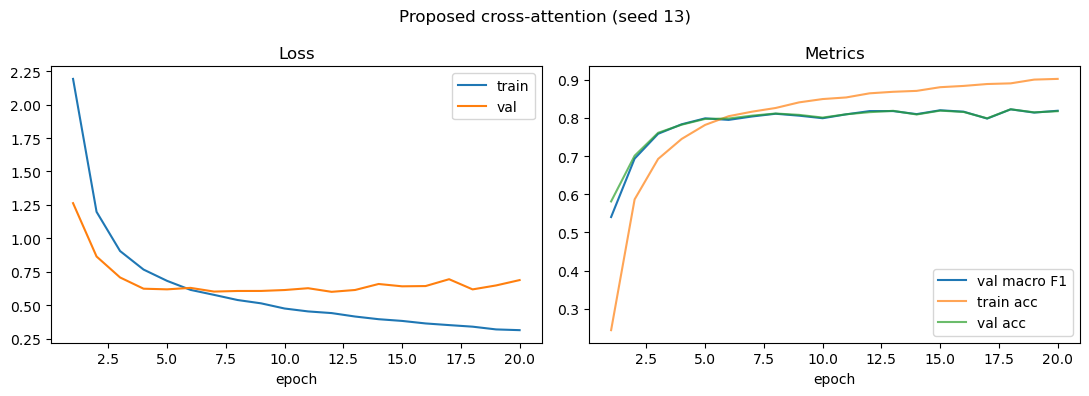

  Test metrics: {'accuracy': 0.8269424823410696, 'macro_precision': 0.8291355533701971, 'macro_recall': 0.8303095729818256, 'macro_f1': 0.8275537881561131, 'loss': 0.5927358108738768}
[Proposed] Experiment 2/10 | data split seed = 14
  Split sizes: train=9248, val=1982, test=1982
  Epoch 01 | train loss 2.1947 acc 0.2383 | val loss 1.2980 acc 0.5797 macroF1 0.5565
  Epoch 02 | train loss 1.2447 acc 0.5748 | val loss 0.8237 acc 0.7356 macroF1 0.7248
  Epoch 03 | train loss 0.8986 acc 0.7054 | val loss 0.7130 acc 0.7634 macroF1 0.7616
  Epoch 04 | train loss 0.7550 acc 0.7539 | val loss 0.6872 acc 0.7750 macroF1 0.7702
  Epoch 05 | train loss 0.6761 acc 0.7806 | val loss 0.6683 acc 0.7780 macroF1 0.7757
  Epoch 06 | train loss 0.6229 acc 0.8032 | val loss 0.6395 acc 0.7901 macroF1 0.7891
  Epoch 07 | train loss 0.5678 acc 0.8228 | val loss 0.6376 acc 0.7911 macroF1 0.7865
  Epoch 08 | train loss 0.5300 acc 0.8327 | val loss 0.6080 acc 0.8022 macroF1 0.8017
  Epoch 09 | train loss 0.4831 

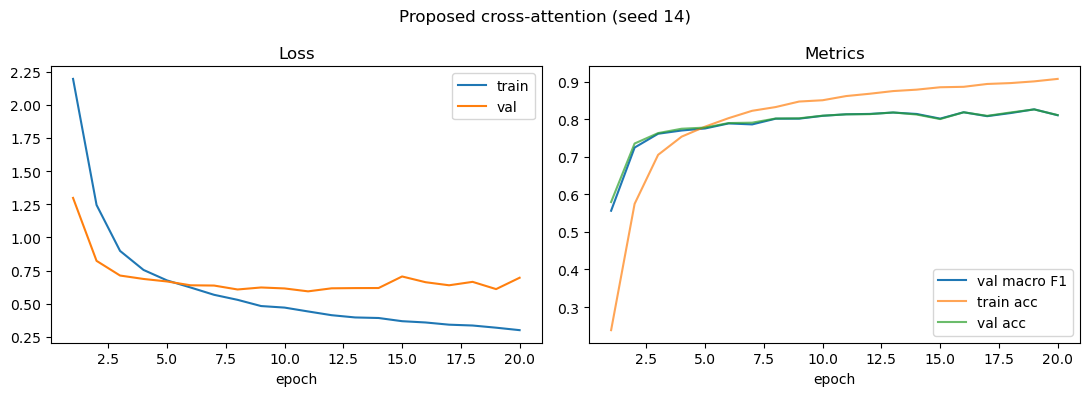

  Test metrics: {'accuracy': 0.8213925327951564, 'macro_precision': 0.8241277454854765, 'macro_recall': 0.8229964974963208, 'macro_f1': 0.8224100192617934, 'loss': 0.6727790097786136}
[Proposed] Experiment 3/10 | data split seed = 16
  Split sizes: train=9248, val=1982, test=1982
  Epoch 01 | train loss 2.1946 acc 0.2423 | val loss 1.2746 acc 0.5943 macroF1 0.5746
  Epoch 02 | train loss 1.2553 acc 0.5693 | val loss 0.8881 acc 0.7114 macroF1 0.7020
  Epoch 03 | train loss 0.9521 acc 0.6850 | val loss 0.7739 acc 0.7351 macroF1 0.7337
  Epoch 04 | train loss 0.8045 acc 0.7407 | val loss 0.6513 acc 0.7901 macroF1 0.7884
  Epoch 05 | train loss 0.7094 acc 0.7735 | val loss 0.7097 acc 0.7654 macroF1 0.7619
  Epoch 06 | train loss 0.6379 acc 0.7956 | val loss 0.6210 acc 0.8047 macroF1 0.8008
  Epoch 07 | train loss 0.5856 acc 0.8116 | val loss 0.5921 acc 0.8108 macroF1 0.8106
  Epoch 08 | train loss 0.5600 acc 0.8217 | val loss 0.5702 acc 0.8128 macroF1 0.8105
  Epoch 09 | train loss 0.5167 

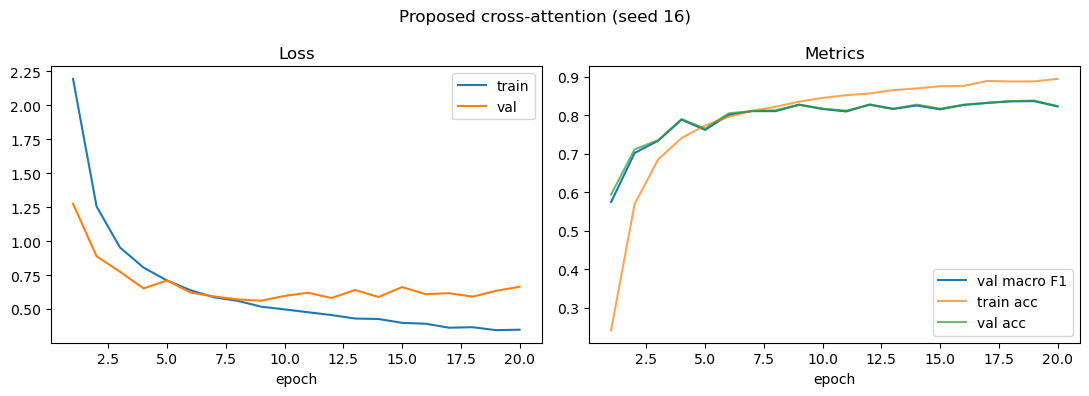

  Test metrics: {'accuracy': 0.8299697275479314, 'macro_precision': 0.8292671678687361, 'macro_recall': 0.8319940727516909, 'macro_f1': 0.8292399567627813, 'loss': 0.601152042299368}
[Proposed] Experiment 4/10 | data split seed = 17
  Split sizes: train=9248, val=1982, test=1982
  Epoch 01 | train loss 2.2987 acc 0.2052 | val loss 1.4504 acc 0.5091 macroF1 0.4462
  Epoch 02 | train loss 1.3178 acc 0.5427 | val loss 0.9087 acc 0.6821 macroF1 0.6738
  Epoch 03 | train loss 0.9513 acc 0.6729 | val loss 0.7348 acc 0.7437 macroF1 0.7395
  Epoch 04 | train loss 0.8017 acc 0.7348 | val loss 0.6666 acc 0.7790 macroF1 0.7780
  Epoch 05 | train loss 0.7268 acc 0.7617 | val loss 0.6407 acc 0.7891 macroF1 0.7873
  Epoch 06 | train loss 0.6488 acc 0.7867 | val loss 0.6399 acc 0.7861 macroF1 0.7846
  Epoch 07 | train loss 0.6021 acc 0.8032 | val loss 0.6331 acc 0.7921 macroF1 0.7934
  Epoch 08 | train loss 0.5512 acc 0.8243 | val loss 0.6147 acc 0.7962 macroF1 0.7928
  Epoch 09 | train loss 0.5222 a

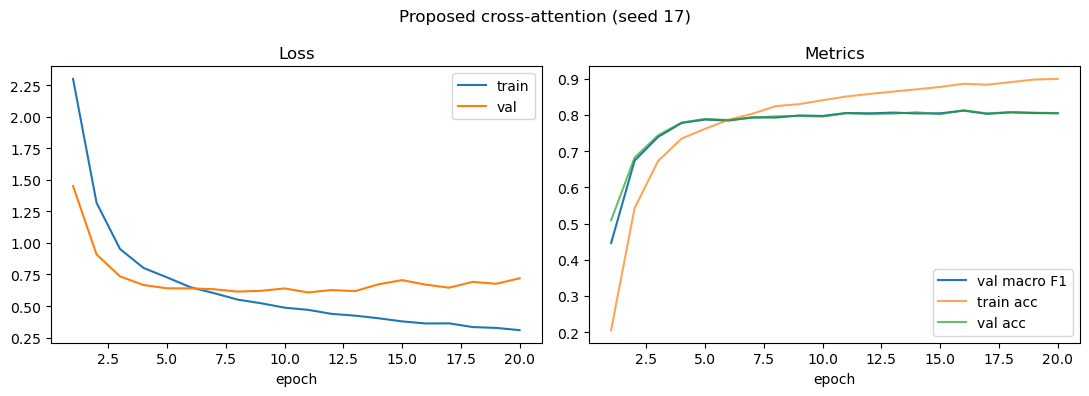

  Test metrics: {'accuracy': 0.8340060544904138, 'macro_precision': 0.8372268910944546, 'macro_recall': 0.8365544045618433, 'macro_f1': 0.8341147854590715, 'loss': 0.5919730404757401}
[Proposed] Experiment 5/10 | data split seed = 45
  Split sizes: train=9248, val=1982, test=1982
  Epoch 01 | train loss 2.3535 acc 0.1780 | val loss 1.4960 acc 0.4748 macroF1 0.4281
  Epoch 02 | train loss 1.3834 acc 0.5084 | val loss 0.9301 acc 0.6751 macroF1 0.6622
  Epoch 03 | train loss 0.9793 acc 0.6737 | val loss 0.7018 acc 0.7624 macroF1 0.7587
  Epoch 04 | train loss 0.7725 acc 0.7565 | val loss 0.6232 acc 0.7871 macroF1 0.7862
  Epoch 05 | train loss 0.6957 acc 0.7823 | val loss 0.5942 acc 0.7972 macroF1 0.7977
  Epoch 06 | train loss 0.6351 acc 0.7965 | val loss 0.5854 acc 0.8063 macroF1 0.8059
  Epoch 07 | train loss 0.5833 acc 0.8140 | val loss 0.5968 acc 0.8017 macroF1 0.8007
  Epoch 08 | train loss 0.5436 acc 0.8271 | val loss 0.5712 acc 0.8042 macroF1 0.8034
  Epoch 09 | train loss 0.5200 

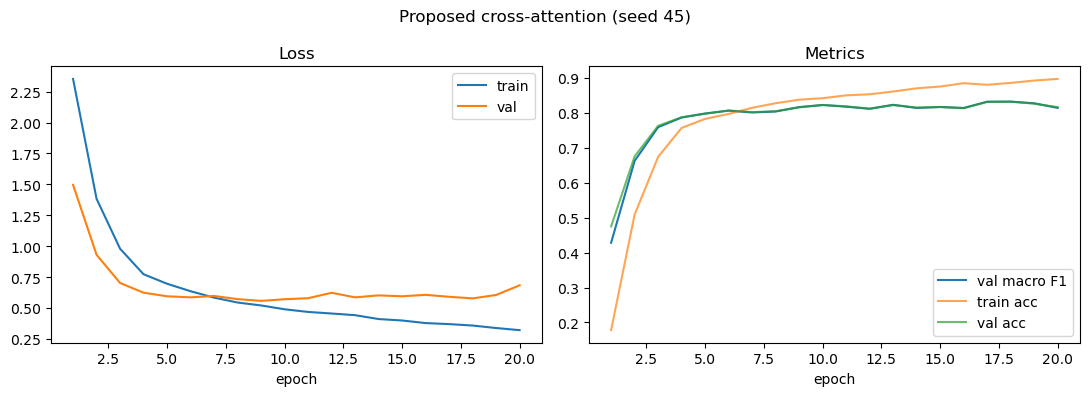

  Test metrics: {'accuracy': 0.8279515640766902, 'macro_precision': 0.829736054250018, 'macro_recall': 0.8324309674519651, 'macro_f1': 0.8277631199787315, 'loss': 0.5828741721716811}
[Proposed] Experiment 6/10 | data split seed = 48
  Split sizes: train=9248, val=1982, test=1982
  Epoch 01 | train loss 2.1927 acc 0.2424 | val loss 1.2926 acc 0.5802 macroF1 0.5520
  Epoch 02 | train loss 1.2251 acc 0.5744 | val loss 0.9082 acc 0.6887 macroF1 0.6770
  Epoch 03 | train loss 0.8930 acc 0.7043 | val loss 0.7080 acc 0.7588 macroF1 0.7529
  Epoch 04 | train loss 0.7382 acc 0.7590 | val loss 0.6455 acc 0.7775 macroF1 0.7752
  Epoch 05 | train loss 0.6689 acc 0.7853 | val loss 0.6055 acc 0.7861 macroF1 0.7865
  Epoch 06 | train loss 0.6131 acc 0.8040 | val loss 0.6068 acc 0.7947 macroF1 0.7939
  Epoch 07 | train loss 0.5588 acc 0.8218 | val loss 0.6526 acc 0.7891 macroF1 0.7897
  Epoch 08 | train loss 0.5329 acc 0.8308 | val loss 0.6234 acc 0.7987 macroF1 0.7984
  Epoch 09 | train loss 0.4936 a

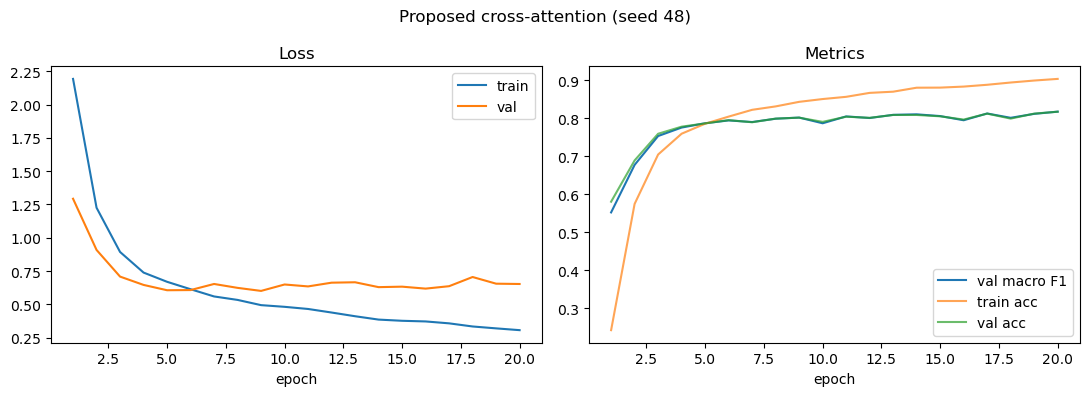

  Test metrics: {'accuracy': 0.8329969727547931, 'macro_precision': 0.8338545245764414, 'macro_recall': 0.8349640532807723, 'macro_f1': 0.8325683524366937, 'loss': 0.6200702985083225}
[Proposed] Experiment 7/10 | data split seed = 53
  Split sizes: train=9248, val=1982, test=1982
  Epoch 01 | train loss 2.2858 acc 0.2053 | val loss 1.4214 acc 0.5015 macroF1 0.4654
  Epoch 02 | train loss 1.3227 acc 0.5252 | val loss 0.8910 acc 0.7043 macroF1 0.6989
  Epoch 03 | train loss 0.9690 acc 0.6680 | val loss 0.7086 acc 0.7477 macroF1 0.7392
  Epoch 04 | train loss 0.8173 acc 0.7283 | val loss 0.7111 acc 0.7422 macroF1 0.7289
  Epoch 05 | train loss 0.7278 acc 0.7636 | val loss 0.6414 acc 0.7916 macroF1 0.7898
  Epoch 06 | train loss 0.6536 acc 0.7907 | val loss 0.6073 acc 0.8007 macroF1 0.8012
  Epoch 07 | train loss 0.5955 acc 0.8108 | val loss 0.5957 acc 0.8037 macroF1 0.8020
  Epoch 08 | train loss 0.5517 acc 0.8236 | val loss 0.6061 acc 0.8118 macroF1 0.8108
  Epoch 09 | train loss 0.5205 

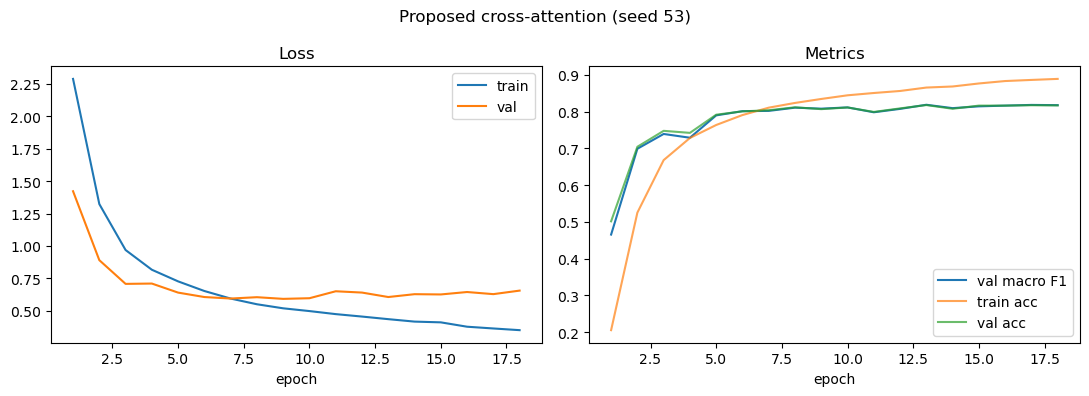

  Test metrics: {'accuracy': 0.8365287588294652, 'macro_precision': 0.8370684335271301, 'macro_recall': 0.8403795334365556, 'macro_f1': 0.8371903833036262, 'loss': 0.5111979624653784}
[Proposed] Experiment 8/10 | data split seed = 58
  Split sizes: train=9248, val=1982, test=1982
  Epoch 01 | train loss 2.2827 acc 0.2109 | val loss 1.3806 acc 0.5550 macroF1 0.5107
  Epoch 02 | train loss 1.2719 acc 0.5559 | val loss 0.8615 acc 0.7094 macroF1 0.7000
  Epoch 03 | train loss 0.9284 acc 0.6843 | val loss 0.6906 acc 0.7644 macroF1 0.7610
  Epoch 04 | train loss 0.7671 acc 0.7476 | val loss 0.6355 acc 0.7820 macroF1 0.7782
  Epoch 05 | train loss 0.6684 acc 0.7841 | val loss 0.6221 acc 0.7916 macroF1 0.7909
  Epoch 06 | train loss 0.6092 acc 0.8073 | val loss 0.6184 acc 0.7931 macroF1 0.7946
  Epoch 07 | train loss 0.5675 acc 0.8187 | val loss 0.5741 acc 0.8063 macroF1 0.8057
  Epoch 08 | train loss 0.5172 acc 0.8325 | val loss 0.5652 acc 0.8138 macroF1 0.8118
  Epoch 09 | train loss 0.4963 

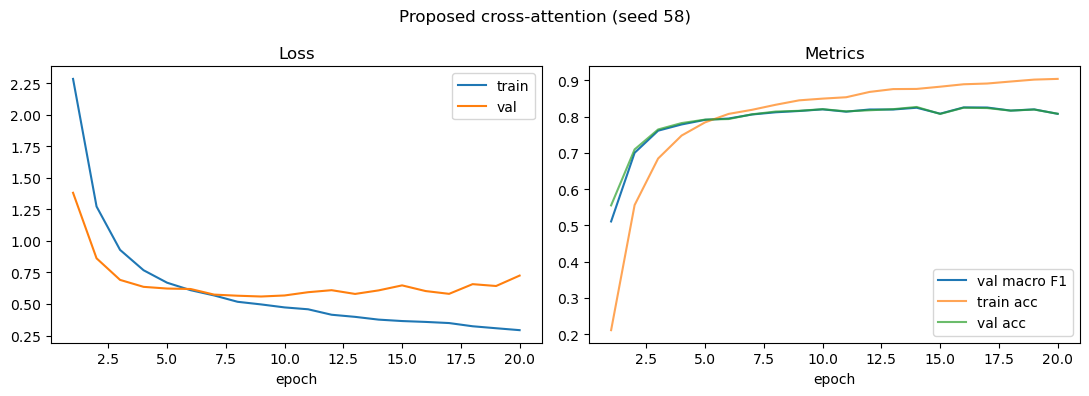

  Test metrics: {'accuracy': 0.8168516649848637, 'macro_precision': 0.8199826358923354, 'macro_recall': 0.8161458154691665, 'macro_f1': 0.8164742371563601, 'loss': 0.6252028723040598}
[Proposed] Experiment 9/10 | data split seed = 72
  Split sizes: train=9248, val=1982, test=1982
  Epoch 01 | train loss 2.1754 acc 0.2350 | val loss 1.3337 acc 0.5499 macroF1 0.5280
  Epoch 02 | train loss 1.2231 acc 0.5879 | val loss 0.8224 acc 0.7255 macroF1 0.7261
  Epoch 03 | train loss 0.9038 acc 0.7064 | val loss 0.7046 acc 0.7583 macroF1 0.7580
  Epoch 04 | train loss 0.7727 acc 0.7463 | val loss 0.6916 acc 0.7598 macroF1 0.7570
  Epoch 05 | train loss 0.7072 acc 0.7696 | val loss 0.6373 acc 0.7871 macroF1 0.7885
  Epoch 06 | train loss 0.6358 acc 0.7980 | val loss 0.6402 acc 0.7871 macroF1 0.7870
  Epoch 07 | train loss 0.6059 acc 0.8063 | val loss 0.6518 acc 0.7841 macroF1 0.7829
  Epoch 08 | train loss 0.5573 acc 0.8178 | val loss 0.6068 acc 0.8052 macroF1 0.8042
  Epoch 09 | train loss 0.5246 

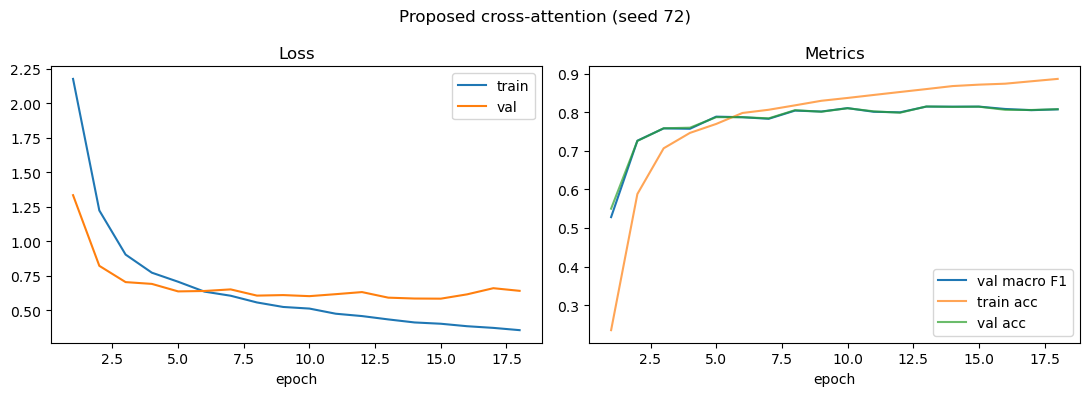

  Test metrics: {'accuracy': 0.8249243188698284, 'macro_precision': 0.8271235660235486, 'macro_recall': 0.8274878171591186, 'macro_f1': 0.8244990928787808, 'loss': 0.5491592977306402}
[Proposed] Experiment 10/10 | data split seed = 102
  Split sizes: train=9248, val=1982, test=1982
  Epoch 01 | train loss 2.2419 acc 0.2262 | val loss 1.2849 acc 0.5843 macroF1 0.5612
  Epoch 02 | train loss 1.2192 acc 0.5819 | val loss 0.9151 acc 0.6847 macroF1 0.6739
  Epoch 03 | train loss 0.8785 acc 0.7027 | val loss 0.6997 acc 0.7639 macroF1 0.7615
  Epoch 04 | train loss 0.7407 acc 0.7629 | val loss 0.6525 acc 0.7820 macroF1 0.7799
  Epoch 05 | train loss 0.6623 acc 0.7894 | val loss 0.6954 acc 0.7654 macroF1 0.7652
  Epoch 06 | train loss 0.6091 acc 0.8073 | val loss 0.6070 acc 0.8022 macroF1 0.8000
  Epoch 07 | train loss 0.5511 acc 0.8250 | val loss 0.6522 acc 0.7987 macroF1 0.7957
  Epoch 08 | train loss 0.5145 acc 0.8394 | val loss 0.5910 acc 0.8103 macroF1 0.8077
  Epoch 09 | train loss 0.490

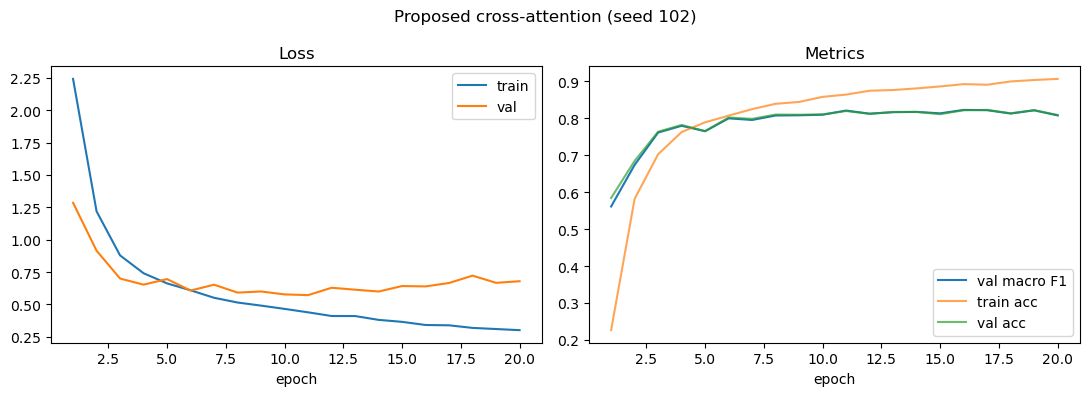

  Test metrics: {'accuracy': 0.82744702320888, 'macro_precision': 0.8328570377700222, 'macro_recall': 0.8271117416727538, 'macro_f1': 0.827907612939568, 'loss': 0.6417915366962734}

[Proposed] Saved per-seed summary: /home/sandy/Document/FusionStyle/results/proposed/cross_attention/all_seeds_summary.csv


,seed,accuracy,macro_precision,macro_recall,macro_f1,loss
0,13,0.826942,0.829136,0.830310,0.827554,0.592736
1,14,0.821393,0.824128,0.822996,0.822410,0.672779
2,16,0.829970,0.829267,0.831994,0.829240,0.601152
3,17,0.834006,0.837227,0.836554,0.834115,0.591973
4,45,0.827952,0.829736,0.832431,0.827763,0.582874


In [12]:
summary_proposed = run_proposed_robustness()
summary_proposed.head()

## 7. Print proposed evaluation summary

In [13]:
agg_proposed, per_class_proposed = aggregate_proposed_results()
print_proposed_evaluation(agg_proposed, per_class_proposed)

AGGREGATION SUMMARY — cross_attention (10 seeds)
          model          metric     mean      std      min      max  ci_95_lower  ci_95_upper  n
cross_attention        accuracy 0.827901 0.005625 0.816852 0.836529     0.823660     0.832143 10
cross_attention macro_precision 0.830038 0.005193 0.819983 0.837227     0.826122     0.833954 10
cross_attention    macro_recall 0.830037 0.006640 0.816146 0.840380     0.825030     0.835045 10
cross_attention        macro_f1 0.827972 0.005664 0.816474 0.837190     0.823701     0.832243 10

PER-CLASS PERFORMANCE SUMMARY — cross_attention (10 seeds)
         Style  F1_Mean   F1_Std   F1_CV%
  conservative 0.773845 0.023068 2.980908
        dressy 0.950282 0.013540 1.424831
        ethnic 0.852620 0.020028 2.349041
         fairy 0.932827 0.017234 1.847457
      feminine 0.764249 0.022813 2.985077
           gal 0.841169 0.014495 1.723152
       girlish 0.667922 0.031495 4.715356
kireime-casual 0.711669 0.013416 1.885138
        lolita 0.949538 0.00